In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'tensorflow', 'keras', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'keras': 'keras==3.14.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'tensorflow.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Decoding and Generation

The language model of that section ended with a cliffhanger. We
trained a network that assigns a probability to every possible next token,
and the moment we asked it to write, two crude recipes presented themselves:
always take the most probable token, or draw one at random from the model's
distribution. Both produced text, and both produced problems, from
continuations that circle through the same phrase to continuations that
wander into gibberish. This section treats the step we improvised there as
a subject of its own. *Decoding*, turning a model over next tokens into
actual sequences, is a design space with its own algorithms, failure modes,
and a modern toolkit [@Graves.2013; @Holtzman.Buys.Du.ea.2020], and it is
largely independent of the network that feeds it: everything we build here
applies unchanged to the gated architectures of the next chapter and to the
largest of large language models.

In [1]:
%matplotlib inline
from d2l import tensorflow as d2l
import math
import numpy as np
import random

## The Decoding Problem

A trained language model supplies conditionals: writing $x_{<t}$ for the
prefix $x_1, \ldots, x_{t-1}$, it turns any prefix into a distribution
$P(x_t \mid x_{<t})$ over the next token. The chain rule of probability
assembles these local judgments into the probability of an entire sequence,

$$P(x_1, \ldots, x_T) = \prod_{t=1}^{T} P(x_t \mid x_{<t}).$$

Decoding asks the inverse question: given the conditionals, which sequence
should we output? One natural answer is the *most probable* sequence, the
argmax of the equation over all candidates. But the number of
candidates is staggering. With vocabulary $\mathcal{V}$ and $T$ tokens to
generate there are $|\mathcal{V}|^T$ sequences to compare; for our modest
1,024-token vocabulary and a 50-token continuation that is $1024^{50} =
2^{500} \approx 10^{150}$ sequences, vastly more than there are atoms in
the observable universe. Evaluating them all, *exhaustive search*, costs
$\mathcal{O}(|\mathcal{V}|^T)$ model evaluations and is out of the
question; every practical decoder explores a vanishing fraction of this
space and must decide, step by step, which fraction.

Intractability is only half of the problem, though. The other half is that
for many uses the most probable sequence is not even what we want. When a
task has essentially one right answer conditioned on the input, a French
sentence to translate, an utterance to transcribe, a function signature to
complete, probability mass concentrates on that answer and hunting for the
argmax is exactly right. But when we ask a model to *write*, there are
astronomically many acceptable continuations, each individually improbable.
A model that has learned this diversity spreads its mass accordingly, and
insisting on the single most probable output discards the diversity we
asked for; we will see shortly that it collapses into dull repetition.
Matching the output's diversity to the model's is what *sampling* does.

These two regimes organize the whole section (the figure).
*Maximization* methods, greedy decoding and beam search, chase the most
probable output and rule tasks with a right answer, such as machine
translation and speech recognition. *Sampling* methods draw from the
model's distribution, reshaped by a small set of dials named temperature,
top-$k$, top-$p$, and min-$p$, and rule open-ended generation: chat,
stories, and everything one now associates with a large language model.

![One trained language model, two families of decoding strategies: maximization for tasks with one right answer, sampling for tasks with many.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rnn-decoding-taskmap.svg)

### A Model to Decode From

We need a trained model to experiment on, and the concise RNN language
model of that section is ideal: small enough to train here in
about a minute, good enough (recall, about 2.4 bits per byte) that its
continuations respond visibly to decoding choices. We retrain it with
exactly the recipe used there.

In [2]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32,
                       num_train=50000, num_val=5000)

In [3]:
with d2l.try_gpu():
    rnn = d2l.RNN(num_inputs=64, num_hiddens=128)
    model = d2l.RNNLM(rnn, vocab_size=len(data.vocab), lr=4)

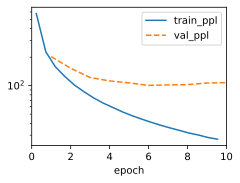

In [4]:
trainer = d2l.Trainer(max_epochs=10, gradient_clip_val=1, num_gpus=1)
model.board.yscale = 'log'
trainer.fit(model, data)

Every decoding strategy in this section interacts with the model through
one narrow interface: hand me the token ids so far, and I will hand you the
logits for the next token. We wrap the trained network in a `step_fn`
implementing that interface, converting the result to a plain NumPy vector
so that the strategies themselves can be written once, in ordinary Python,
with no framework in sight. Any model that can fill this interface, today's
RNN, next chapter's LSTM, a transformer, can be decoded by every algorithm
below.

In [5]:
def step_fn(ids):  # Token ids in, numpy logits for the next token out
    logits = model(d2l.tensor([ids]))
    return d2l.numpy(logits)[0, -1]

Note the deliberate extravagance: each call re-runs the network over the
*entire* prefix just to produce one vector of logits. We will tally the
cost of this convenience at the end of the section.

## Greedy Decoding

The simplest decoder commits, at every step, to the single most likely
token:

$$x_t = \operatorname*{argmax}_{x \in \mathcal{V}} P(x \mid x_{<t}).$$

The algorithm is a one-line loop: score, take the argmax, append, repeat.
It costs one model evaluation per token, $\mathcal{O}(|\mathcal{V}| T)$
work in total, and it is deterministic: the same prefix always yields the
same continuation.

In [6]:
def decode_greedy(text, num_tokens=50):
    ids = data.tokenizer.encode(text)
    for _ in range(num_tokens):
        ids.append(int(step_fn(ids).argmax()))
    return data.tokenizer.decode(ids)

for text in ('the time traveller', 'it seemed to me that'):
    print(repr(decode_greedy(text)))

'the time traveller the\nside, I saw\nlittleess of the\nfour of the floor of the\nsunned and\npresented\ntheseength, the\nfour of the faint of'


'it seemed to me that the\nhim, and that the\nfour of the floor of the\nsunned and\npresented\ntheseength, the\nfour of the faint of\nthese, I'


The output is locally plausible Wells, but it drifts toward the generic,
and it drifts *predictably*: the two different prefixes soon funnel into
the same stock phrases, and, depending on the training run, the
continuation may lock into a verbatim repeating cycle outright. Two
distinct flaws are on display. The first is *myopia*: a sequence of
locally best tokens need not be the best sequence. Suppose the vocabulary
holds four tokens $A$, $B$, $C$, and $D$, and at the first step the model
assigns them probabilities 0.5, 0.2, 0.2, and 0.1. Greedy picks $A$.
Conditioned on $A$, suppose the best continuation runs through $B$ with
probability 0.4, then 0.4, then 0.6: the greedy sequence has probability
$0.5 \times 0.4 \times 0.4 \times 0.6 = 0.048$. Had we accepted the
*second*-best token $C$ (probability 0.3) at the second step, the changed
conditioning might offer 0.6 and 0.6 next, for a total of $0.5 \times 0.3
\times 0.6 \times 0.6 = 0.054$. Taking one locally suboptimal step bought a
globally better sequence; greedy can never make that trade.

The second flaw runs deeper than myopia. Greedy decoding feeds its own
argmax back in as context, and repetition is self-reinforcing: once a
phrase has appeared twice, its third occurrence is *more* probable still,
since the model has learned that text which repeats tends to keep
repeating. The argmax feedback loop rides this gradient toward repetition
and, given enough maximization pressure, into a literal fixed cycle.
@Holtzman.Buys.Du.ea.2020 documented the phenomenon, aptly named
*neural text degeneration*, in models a thousand times larger than ours:
maximization-based decoding of open-ended text produces output that is
repetitive, low-diversity, and measurably unlike human text, no matter how
good the underlying model is. Keep that in mind as we now fix the first
flaw, myopia, and watch the second one get worse.

## Beam Search

Decoding strategies live on a spectrum between the two extremes we have
met: greedy search commits instantly and exhaustive search never commits at
all. *Beam search* interpolates with a single knob, the *beam size* $k$:
keep the $k$ most probable prefixes alive at every step. At the first step
it selects the $k$ highest-probability tokens; thereafter, each of the $k$
surviving prefixes is extended by every token in the vocabulary, the
resulting $k \cdot |\mathcal{V}|$ candidates are scored by their cumulative
log-probability, and only the best $k$ survive. Greedy search is the
special case $k = 1$; exhaustive search is the limit where $k$ outgrows the
candidate count and pruning never happens.

![Beam search with beam size 2 over a five-token vocabulary. At every step each surviving prefix is expanded over the whole vocabulary and only the two highest-scoring prefixes are kept; the candidates here are $A$, $C$, then $AB$, $CE$, then $ABD$, $CED$.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rnn-beam-tree.svg)

the figure traces a worked example with $k = 2$ over the toy
vocabulary $\mathcal{V} = \{A, B, C, D, E\}$ and three generation steps.
Suppose the two most probable first tokens are $A$ and $C$; they form the
initial beam. At the second step we compute, for every $x_2 \in
\mathcal{V}$, the extension scores

$$\begin{aligned}P(A, x_2 \mid x_{\leq m}) &= P(A \mid x_{\leq m}) P(x_2 \mid A, x_{\leq m}),\\ P(C, x_2 \mid x_{\leq m}) &= P(C \mid x_{\leq m}) P(x_2 \mid C, x_{\leq m}),\end{aligned}$$

ten numbers in all (here $x_{\leq m}$ denotes the given prefix), and keep
the two largest, say $P(A, B \mid x_{\leq m})$ and $P(C, E \mid x_{\leq
m})$. The third step repeats the recipe from the survivors $AB$ and $CE$,
yielding say $ABD$ and $CED$. Note what pruning bought us: instead of
$5^3 = 125$ sequences we scored $5 + 10 + 10 = 25$, and in general beam
search costs $\mathcal{O}(k |\mathcal{V}| T)$, a factor $k$ more than
greedy and exponentially less than exhaustive search.

One correction is needed before we can rank the finished candidates.
Log-probabilities of tokens are non-positive, so the cumulative score of a
sequence only falls as it grows, and comparing raw scores systematically
favors short candidates (an acute issue once an end-of-sequence token can
terminate some beams early). The standard remedy is *length normalization*
[@Wu.Schuster.Chen.ea.2016]: rank each candidate of generated length
$L$ by

$$\frac{1}{L^\alpha} \sum_{t=m+1}^{m+L} \log P(x_t \mid x_{<t}),$$

where $\alpha$ (typically around 0.75) interpolates between no correction
($\alpha = 0$) and the per-token average log-probability ($\alpha = 1$).
The implementation below follows the recipe directly. Finished candidates
(those that produced `eos_id`) pass through unchanged from round to round;
live ones are expanded and rescored. Since the global top $k$ can contain
at most $k$ continuations of any single prefix, it suffices to consider
each beam's $k$ best tokens rather than all $|\mathcal{V}|$ of them. Like
the rest of this section's toolkit, everything is plain Python against
plain arrays, so this same function will decode next chapter's translation
model without modification.

In [7]:
def beam_search(step_fn, prefix, num_tokens, beam_size=4,
                alpha=0.75, eos_id=None):
    """Length-normalized beam search (score = log P / len^alpha).
    Returns candidates sorted best-first; [0][1] is the argmax sequence."""
    def log_softmax(logits):
        logits = [float(l) for l in logits]
        m = max(logits)
        lse = m + math.log(sum(math.exp(l - m) for l in logits))
        return [l - lse for l in logits]
    score = lambda logp, ids: logp / max(1, len(ids) - len(prefix))**alpha
    beams = [(0.0, list(prefix), False)]  # (log-prob, sequence, finished)
    for _ in range(num_tokens):
        if all(done for _, _, done in beams):
            break
        candidates = [b for b in beams if b[2]]  # Finished pass through
        for logp, ids, _ in (b for b in beams if not b[2]):
            logprobs = log_softmax(step_fn(ids))
            best = sorted(range(len(logprobs)),
                          key=lambda i: -logprobs[i])[:beam_size]
            candidates += [(logp + logprobs[i], ids + [i], i == eos_id)
                           for i in best]
        beams = sorted(candidates, key=lambda b: score(b[0], b[1]),
                       reverse=True)[:beam_size]
    return sorted([(score(logp, ids), ids) for logp, ids, _ in beams],
                  reverse=True)

Let's decode the same two prefixes as before, with $k = 1$ (which
reproduces greedy decoding) and $k = 4$. To make the repetition failure
measurable rather than anecdotal we also report *distinct-3*, the fraction
of distinct 3-grams among all 3-grams of the continuation: a value of 1
means no 3-gram ever recurs, and a continuation stuck in a loop scores
close to 0.

In [8]:
def distinct(ids, n=3):
    grams = [tuple(ids[i:i + n]) for i in range(len(ids) - n + 1)]
    return len(set(grams)) / max(1, len(grams))

for text in ('the time traveller', 'it seemed to me that'):
    pre = data.tokenizer.encode(text)
    for k in (1, 4):
        score, ids = beam_search(step_fn, pre, 40, beam_size=k)[0]
        print(f'k={k}, score {score:.2f}, distinct-3 '
              f'{distinct(ids[len(pre):]):.2f}: '
              f'{data.tokenizer.decode(ids)!r}')

k=1, score -4.74, distinct-3 0.95: 'the time traveller the\nside, I saw\nlittleess of the\nfour of the floor of the\nsunned and\npresented\ntheseength'


k=4, score -3.16, distinct-3 0.45: "the time traveller the Time Traveller.\n\n'There I found a\npresented.\n\n'There I found a\npresented.\n\n'There I found a"


k=1, score -4.62, distinct-3 0.95: 'it seemed to me that the\nhim, and that the\nfour of the floor of the\nsunned and\npresented\ntheseength, the\nfour'


k=4, score -3.15, distinct-3 0.58: "it seemed to me that I had\ndisappef.\n\n'There I found a\npresented.\n\n'There I found a\npresented.\n\n'"


Beam search mostly does what it promises: at $k = 4$ it usually finds
continuations that the model scores better than the greedy ones, curing the
myopia of the four-token example above. It remains an approximate search,
though, so on a given prefix a wider beam can occasionally come back
*worse*. And yet look at the text. The continuations it returns lock into a
literal loop, repeating one phrase verbatim, and the distinct-3 numbers
collapse far below the values sampling will achieve; where greedy decoding
already loops, beam search simply finds a higher-probability loop to be
stuck in. This is the
degeneration mechanism at work: the better a maximizer gets, the deeper
it digs into the repetitive mode of the distribution. The lesson
generalizes far beyond RNNs. For open-ended text
the argmax itself is a bad target, and no improvement in search can fix a
correctly solved wrong problem [@Holtzman.Buys.Du.ea.2020].

It is tempting to conclude that more search at least helps the tasks where
maximization *is* the right target. Curiously, it does not: in machine
translation, pushing the beam from a handful to hundreds reliably *lowers*
translation quality. Ever-larger beams find ever-higher-probability
outputs, and those outputs are systematically shorter and blander, until
the search starts uncovering pathologies of the model itself, such as an
empty translation that outscores every real one. Length normalization
softens this large-beam curse without eliminating it, so practitioners
stop at small beams, typically $k$ between 4 and 10, where the search
fixes local myopia but is not yet strong enough to exploit the model's
blind spots.

Where does beam search live today? Exactly where its assumptions hold:
speech recognition and machine translation systems
[@Sutskever.Vinyals.Le.2014; @Wu.Schuster.Chen.ea.2016] still
beam-decode, and *constrained* decoding, which forces the output to obey a
grammar, a JSON schema, or an API signature, is beam search over the valid
continuations. Your chat assistant, however, does not use it: open-ended
dialogue sits firmly in the second family, to which we now turn.

## Sampling and Its Dials

If the model's distribution is worth trusting, the principled way to
generate is to *sample* from it: draw $x_t \sim P(x_t \mid x_{<t})$,
append, repeat. Text produced this way is distributed exactly as the model
believes text should be, with all the diversity that maximization threw
away and none of its repetition traps. The catch appears in the tail. Our
model spreads small probability over a thousand tokens, a large one over
hundreds of thousands, and although each unlikely token is individually
negligible, their combined mass at every step is not. Sampling therefore
regularly hits tokens the model itself considers near-nonsense, and one
absurd token, fed back as context, can derail everything after it.
@Holtzman.Buys.Du.ea.2020 call this the *unreliable tail*: the
model's estimates are relatively trustworthy at the head of the
distribution and mostly noise far down the ranking, so the fix is to
sample from a reshaped, truncated distribution. Each of the dials below is
one way of doing that.

**Temperature** rescales before sampling. Dividing every logit $o_x$ by a
temperature $T > 0$ gives

$$P_T(x \mid x_{<t}) = \frac{\exp(o_x / T)}{\sum_{x' \in \mathcal{V}} \exp(o_{x'} / T)} \propto P(x \mid x_{<t})^{1/T}.$$

At $T = 1$ we sample the model as-is; as $T \to 0$ the distribution
sharpens toward its mode and sampling becomes greedy decoding; as $T$
grows it flattens toward uniform. Temperature trades diversity against
safety smoothly, but it reshapes head and tail together: cooling the
distribution enough to suppress the tail also crushes legitimate variety
at the head.

**Top-$k$** truncates by *count*: keep the $k$ most probable tokens,
renormalize, and sample [@Radford.Wu.Child.ea.2019]. **Top-$p$** (or
*nucleus*) sampling truncates by *mass*: keep the smallest set of
most-probable tokens whose cumulative probability reaches $p$, for example
$p = 0.9$ [@Holtzman.Buys.Du.ea.2020]. The difference matters because
the model's confidence varies wildly from step to step. Where our model is
nearly certain of the next token, a fixed $k = 20$ needlessly admits
nineteen bad options; mid-sentence, where dozens of words are genuinely
plausible, the same $k$ may cut off real diversity. Top-$p$ adapts better,
keeping few tokens when the head is heavy and many when it is flat, but it
too misbehaves on peaked distributions: if the top token already holds
0.95 of the mass, top-$p$ with $p = 0.9$ keeps exactly one token and acts
greedily even where the runner-up was perfectly acceptable.

**Min-$p$** scales the cutoff by the model's own confidence
[@Nguyen.Baker.Neo.ea.2025]: keep every token whose probability is at
least $p_{\min}$ times that of the most probable token, e.g. $p_{\min} =
0.05$. When the model is sure, the bar is high and few tokens pass; when
the model is uncertain, the bar drops and the genuine variety survives.
This relative rule holds up notably better at high temperatures, where
creative sampling wants to operate and where absolute-threshold rules
admit the noise floor wholesale.

### A Unified Sampler

All four dials act on the same object, the next-token distribution, so a
single function can host them. `sample_next` turns one vector of logits
into one token id: greedy if asked, otherwise temperature-scaled sampling
after optional top-$k$, top-$p$, and min-$p$ truncation. Note how each
truncation rule is just a different cut of the same sorted-by-probability
order, a pure function of the distribution; we exploit that shortly to
visualize all three at once. Like `beam_search` it is written in plain
Python, and it draws through an explicit `rng` (anything with a
`random()` method, such as `numpy.random.default_rng(seed)`) so that
generation is reproducible.

In [9]:
def sample_next(logits, strategy='greedy', temperature=1.0,
                k=None, p=None, min_p=None, rng=None):
    """Choose the next token id from a 1-D numpy logits array.
    strategy: 'greedy' | 'sample' (with optional top-k / top-p / min-p
    truncation applied to the temperature-scaled distribution)."""
    logits = [float(l) for l in logits]
    if strategy == 'greedy' or temperature == 0:
        return max(range(len(logits)), key=lambda i: logits[i])
    m = max(logits)
    probs = [math.exp((l - m) / temperature) for l in logits]
    total = sum(probs)
    probs = [q / total for q in probs]
    order = sorted(range(len(probs)), key=lambda i: -probs[i])
    keep = len(order)
    if k is not None:  # Top-k: the k most probable tokens
        keep = min(keep, k)
    if p is not None:  # Top-p: smallest head with cumulative mass >= p
        mass, n = 0.0, 0
        while mass < p and n < len(order):
            mass, n = mass + probs[order[n]], n + 1
        keep = min(keep, n)
    if min_p is not None:  # Min-p: within a factor of the top token
        bar = min_p * probs[order[0]]
        keep = min(keep, sum(q >= bar for q in probs))
    kept = order[:keep]
    rng = random if rng is None else rng
    r = rng.random() * sum(probs[i] for i in kept)
    for i in kept:
        r -= probs[i]
        if r <= 0:
            return i
    return kept[-1]

`generate` is the loop we have been writing by hand all along: query
`step_fn`, choose via `sample_next` (extra keyword arguments pass straight
through to it), append, and stop early if an end-of-sequence token
appears. Open-ended generation has no such token, so our demonstrations
simply run for a fixed length; the translation models of the next chapter
set `eos_id` and let the model decide when it is done.

In [10]:
def generate(step_fn, prefix, num_tokens, eos_id=None, **strategy):
    """Autoregressive generation. step_fn(ids: list[int]) -> numpy logits
    for the next token. Returns prefix + continuation (stops on eos_id)."""
    ids = list(prefix)
    for _ in range(num_tokens):
        ids.append(sample_next(step_fn(ids), **strategy))
        if eos_id is not None and ids[-1] == eos_id:
            break
    return ids

A toy distribution makes the truncation rules concrete. Five tokens carry
probabilities 0.45, 0.25, 0.15, 0.10, and 0.05. Top-$k$ with $k = 2$ may
only ever emit tokens 0 and 1; top-$p$ with $p = 0.85$ keeps three tokens,
since the cumulative mass first reaches 0.85 at the third; min-$p$ with
$p_{\min} = 0.5$ keeps the tokens with probability at least $0.5 \times
0.45 = 0.225$, which is again tokens 0 and 1.

In [11]:
logits, rng = np.log([0.45, 0.25, 0.15, 0.1, 0.05]), np.random.default_rng(0)
print('greedy:', sample_next(logits))
for dial in (dict(k=2), dict(p=0.85), dict(min_p=0.5)):
    draws = [sample_next(logits, strategy='sample', rng=rng, **dial)
             for _ in range(15)]
    print(dial, draws)

greedy: 0
{'k': 2} [0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1]
{'p': 0.85} [0, 2, 1, 0, 0, 0, 0, 1, 1, 1, 0, 2, 2, 1, 1]
{'min_p': 0.5} [1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0]


### One Distribution, Three Cutoffs

Toy numbers are one thing; here is the real object every dial acts on. We
query the trained model once and plot its entire next-token distribution,
sorted by decreasing probability, on logarithmic axes (the shape is
Zipf-like, as that section would lead us to expect). On
this plot each truncation rule is a single line. Top-$k$ is a vertical cut
at rank $k$, wherever the probabilities happen to lie. Top-$p$ is a
vertical cut at the rank where the cumulative mass reaches $p$, so its
position slides with the shape of the head. Min-$p$ is a *horizontal* cut
at $p_{\min}$ times the top probability: every token above the line
survives, and the line itself rides up and down with the model's
confidence. Everything below and to the right of the cuts is the
unreliable tail that truncation exists to remove.

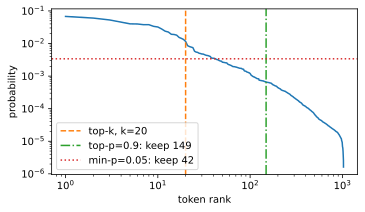

In [12]:
def next_probs(text):  # Sorted next-token distribution after a prefix
    logits = step_fn(data.tokenizer.encode(text))
    probs = np.exp(logits - logits.max())
    return np.sort(probs / probs.sum())[::-1]

probs = next_probs('the time traveller')
n_p = int((np.cumsum(probs) < 0.9).sum()) + 1
n_m = int((probs >= 0.05 * probs[0]).sum())
d2l.set_figsize((5.5, 3))
d2l.plt.loglog(np.arange(1, len(probs) + 1), probs, color='C0')
d2l.plt.axvline(20, color='C1', ls='--', label='top-k, k=20')
d2l.plt.axvline(n_p, color='C2', ls='-.', label=f'top-p=0.9: keep {n_p}')
d2l.plt.axhline(0.05 * probs[0], color='C3', ls=':',
                label=f'min-p=0.05: keep {n_m}')
d2l.plt.xlabel('token rank')
d2l.plt.ylabel('probability')
d2l.plt.legend()

The adaptivity argument is now checkable: apply the same dials after two
different prefixes and compare the kept sets. Top-$k$ keeps twenty tokens
regardless. The other two rules track the model's confidence (how
confident it is after a given prefix varies from training run to training
run; the printed top probability tells you what this one thinks): the
more certain the model, the smaller the top-$p$ and min-$p$ sets tend to
be. That is the behavior we wanted: strict where the model is sure,
permissive where it is genuinely uncertain.

In [13]:
for text in ('the time traveller', 'it seemed to me that'):
    probs = next_probs(text)
    n_p = int((np.cumsum(probs) < 0.9).sum()) + 1
    n_m = int((probs >= 0.05 * probs[0]).sum())
    print(f'{text!r}: top prob {probs[0]:.2f}, top-k keeps 20, '
          f'top-p keeps {n_p}, min-p keeps {n_m}')

'the time traveller': top prob 0.07, top-k keeps 20, top-p keeps 149, min-p keeps 42
'it seemed to me that': top prob 0.20, top-k keeps 20, top-p keeps 53, min-p keeps 11


### The Same Prefix Under Every Strategy

Time to hear the dials rather than plot them. First, temperature alone: at
$T = 0.5$ the text hugs the model's mode and inherits some of greedy's
repetitiveness, at $T = 1$ it is diverse but occasionally derails into
tail nonsense, already reaching for tokens whose bytes no longer decode to
valid text (the replacement characters below), and at $T = 2$ the flattened
distribution produces gibberish outright.

In [14]:
prefix = data.tokenizer.encode('the time traveller')
for T in (0.5, 1.0, 2.0):
    out = generate(step_fn, prefix, 50, strategy='sample', temperature=T,
                   rng=np.random.default_rng(0))
    print(f'T={T}: {data.tokenizer.decode(out)!r}')

T=0.5: "the time travellerce a\nbut in.\n\n'That's guessy, I saw\nstrdle. L\n\n\nmake, and I\npresently read\nscessively\nfour;"


T=1.0: 'the time travellers and.\nI either him to and approumpessity upon me. It was\nbeto either� lever of proenox orually the twoworic, and gallery were very siln'


T=2.0: 'the time traveller hech.\near�ich part seemed� along the they wereullh�ffently once;off perhaps onlyndwas above under such betbleag arearereive\x06istme aser j onether; round witheen'


Finally, the whole menu on one prefix, with the distinct-3 diversity score
alongside. Greedy is deterministic and generic, when not stuck in a loop
outright; pure sampling is diverse but erratic; the truncated samplers
occupy the useful middle, keeping the
diversity that maximization destroyed (their distinct-3 stays near 1)
while cutting the tail that pure sampling trips over. This is why some
combination of temperature with top-$p$ or min-$p$ is the default in
essentially every deployed text generator today.

In [15]:
strategies = {'greedy': dict(strategy='greedy'),
              'T=1.0': dict(strategy='sample'),
              'top-k': dict(strategy='sample', k=20),
              'top-p': dict(strategy='sample', p=0.9),
              'min-p': dict(strategy='sample', min_p=0.05)}
for name, s in strategies.items():
    out = generate(step_fn, prefix, 50, rng=np.random.default_rng(0), **s)
    print(f'{name:>7} (distinct-3 {distinct(out[len(prefix):]):.2f}): '
          f'{data.tokenizer.decode(out)!r}')

 greedy (distinct-3 0.85): 'the time traveller the\nside, I saw\nlittleess of the\nfour of the floor of the\nsunned and\npresented\ntheseength, the\nfour of the faint of'


  T=1.0 (distinct-3 1.00): 'the time travellers and.\nI either him to and approumpessity upon me. It was\nbeto either� lever of proenox orually the twoworic, and gallery were very siln'


  top-k (distinct-3 1.00): "the time travellerces, and I went downsetulate\nMy and\ns the breathing of detewomion, it's have been during. Soets and spiming. For\nmyself he"


  top-p (distinct-3 1.00): "the time travellercondon of white had come me thinks upon\nthated; and eitherance of\nbacstand. So who Man oner, and disappceptuooing.\n\n'Aman, and you"


  min-p (distinct-3 1.00): "the time traveller\nthereenumy of a marms of us. 'I bewered.\n\n'Tondeedorce the\nwellorner, the night, and that was the starteroots!"


Our small model cannot make any of these continuations *good*; what it
makes visible is that they are *different*, in exactly the directions the
theory predicts, and the differences only grow with model quality. The
same dials, at the same typical settings, ship in every large language
model API you will ever call.

## Evaluation and Efficiency

### Evaluating Generated Text

How would we decide, beyond eyeballing, which strategy wrote better text?
Perplexity, our faithful metric so far, is of surprisingly little help. It
evaluates the *model*: how well the predicted conditionals compress text
that humans actually wrote. It says nothing about any particular sample,
and scoring a sample by its own model probability would just reinvent
maximization, crowning the repetitive beam-search output we have already
rejected. A generation strategy is not better because its output is more
probable; the whole point of the sampling family is to deviate from the
mode on purpose.

The honest target is human judgment: can readers distinguish the model's
text from text people wrote, and which do they prefer? Alongside such
judgments, automated proxies catch specific failure modes: diversity
statistics such as our distinct-3 flag degeneration, and repetition and
length statistics serve as cheap regression tests for a decoding stack.
Tasks with a reference answer are easier to score; the next chapter
evaluates translations by their overlap with reference translations, the
setting where maximization and automatic metrics agree best.

At the frontier, evaluation has become a discipline of its own. Modern
practice ranks systems by collecting human preferences between paired
responses, and increasingly by asking a strong language model to play the
judge, with well-documented blind spots of its own. We return to
generation-quality evaluation in the context of large language models
later in the book; for now, the operational summary is that perplexity
selects the model, while humans, or proxies for them, select the decoding
strategy.

### The Cost of Generation

One last practical concern, and a preview. Our `step_fn` re-runs the
network over the whole prefix for every token generated, so a $T$-token
continuation costs $\mathcal{O}(T^2)$ cell updates, and generation is
inherently *sequential*: unlike training, where all time steps of a known
sequence are processed together, token $t + 1$ cannot be scored before
token $t$ exists. For a recurrent network the quadratic part is pure
waste: the hidden state already summarizes the prefix, so carrying it
forward (as `predict` in that section did) makes each new
token cost $\mathcal{O}(1)$, independent of everything that came before.
That constant-memory, constant-time-per-token property is a defining
virtue of recurrence, and that section builds architectures
that keep it at much higher quality. The sequential bottleneck, meanwhile,
has spawned a toolbox of its own, most prominently *speculative decoding*,
where a small draft model proposes several tokens and the large model
verifies them in one parallel pass; we return to serving-time efficiency
when we meet large language models.

## Summary

Decoding turns a language model's conditionals into sequences, and the
choice of strategy is a modeling decision in its own right. Maximization
targets the most probable output: greedy decoding takes the local argmax
and is myopic; beam search keeps the $k$ best prefixes under the
length-normalized score the equation and fixes myopia at
$k$ times the cost. Maximization suits tasks with an essentially unique
answer, but for open-ended text its target is wrong: the argmax of a good
model is repetitive and dull, and a stronger search only finds it faster.
Sampling draws from the model's distribution, reshaped by temperature
the equation and truncated by top-$k$ (fixed count), top-$p$
(fixed mass), or min-$p$ (fixed fraction of the top probability, hence
adaptive to the model's confidence). Perplexity evaluates the model rather
than its samples; judging generated text requires humans or proxies for
them. Finally, generating naively re-runs the model over a growing prefix
for every new token; a recurrent state cuts this to constant work per
token, a property the next chapter's architectures inherit.

## Exercises

1. Implement a *repetition penalty*: in `sample_next`, divide the
   probability of every token already present in the generated sequence by
   a constant $\theta > 1$ before truncation (you will need to thread the
   generated ids through). Decode greedily with $\theta = 1.2$. Does it
   cure the loops? What legitimate text does it punish?
1. In the figure, could the best candidate after three
   steps (by cumulative probability) fail to contain the best candidate
   after two steps as its prefix? Construct explicit probabilities or
   prove it impossible. What does your answer imply about how beam search
   can miss the true argmax sequence?
1. Can exhaustive search be seen as a special case of beam search? For
   which beam size do the two coincide?
1. Add an `eos_id` to the beam-search demonstration (for instance the
   token id of a newline) and vary $\alpha \in \{0, 0.75, 1.5\}$ at
   $k = 4$. Compare the lengths and scores of the winning candidates and
   explain the trend using the equation.
1. At temperature $T = 1.5$, tune $p$ for top-$p$ and $p_{\min}$ for
   min-$p$ until each just keeps continuations coherent. Which setting
   preserves more diversity (distinct-3) at matched coherence? Compare
   your finding with those of @Nguyen.Baker.Neo.ea.2025 .
1. Once you have trained the sequence-to-sequence translation model of the
   next chapter, decode it with `beam_search` for
   $k \in \{1, 2, 4, 8, 16\}$. Measure translation quality and decoding
   time as functions of $k$. Where does quality peak, and why does it not
   keep improving?
1. Constrained sampling: ban a set of tokens (say, every token whose text
   contains the letter "e") by masking their logits to $-\infty$ before
   calling `sample_next`. Why is banning a *word* harder than banning a
   token under a subword tokenizer? What can go wrong at the boundary
   between two tokens?

[Discussions](https://d2l.discourse.group/t/338)